# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_pickle('../data/processed/train.pkl')

# Data Visualization and Numerical Analysis

In [4]:
df.head(5)

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
3897,C5652,Female,Teenager,Multan,4/16/2024,O9652,12/7/2024,Burger King,Fries,Fast Food,2,554.07,Cash,4,7/25/2025,242,Active,3.012153,10/12/2024,Cancelled
5628,C2031,Other,Teenager,Islamabad,3/15/2025,O6031,7/8/2025,McDonald's,Fries,Dessert,1,1001.93,Card,16,12/16/2024,426,Active,4.000000,12/15/2024,Delivered
1756,C4096,Male,Teenager,Lahore,6/8/2024,O8096,3/23/2024,Subway,Fries,Dessert,2,649.95,Cash,24,4/21/2025,125,Inactive,3.012153,2/12/2025,Cancelled
2346,C3933,Other,Adult,Karachi,7/18/2024,O7933,6/6/2024,McDonald's,Sandwich,Continental,5,300.25,Cash,42,6/20/2025,190,Inactive,3.000000,7/7/2025,Delivered
2996,C1335,Male,Adult,Peshawar,5/11/2024,O5335,8/21/2024,Pizza Hut,Fries,Dessert,2,1363.64,Cash,2,6/10/2025,385,Inactive,3.012153,4/13/2025,Cancelled


In [5]:
df.describe()

,quantity,price,order_frequency,loyalty_points,rating
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,2.996667,798.353969,25.444583,249.502708,3.010474
std,1.417448,406.801578,14.328560,144.468159,1.150908
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,434.667500,13.000000,124.000000,2.000000
50%,3.000000,803.280000,25.000000,249.000000,3.012153
75%,4.000000,1150.575000,38.000000,377.000000,4.000000
max,5.000000,1499.730000,50.000000,500.000000,5.000000


In [7]:
df.shape

(4800, 20)

In [10]:
df['rating'] = df['rating'].round(0).astype(int)

Text(0, 0.5, 'Count')

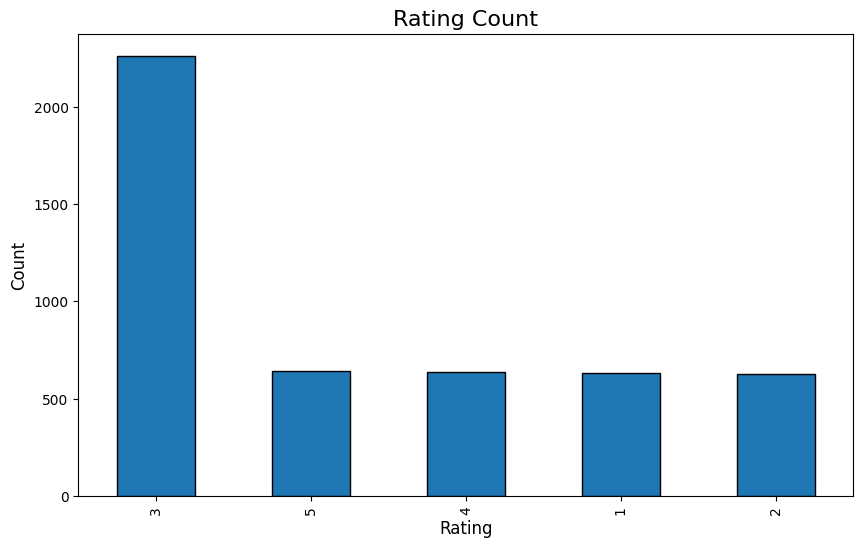

In [11]:

rating_count = df['rating'].value_counts()


plt.figure(figsize=(10,6))

rating_count.plot(kind='bar', edgecolor='black')

plt.title('Rating Count', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

In [29]:
from scipy.stats import chi2_contingency
import numpy as np

contingency = pd.crosstab(df['rating'], df['delivery_status'])

print(contingency)
stat, p, dof, expected = chi2_contingency(contingency)

alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')


delivery_status  Cancelled  Delayed  Delivered
rating                                        
1                        0      301        331
2                        0      293        333
3                     1586      330        346
4                        0      309        330
5                        0      320        321
p value is 0.0
Dependent (reject H0)


In [30]:
contingency = pd.crosstab(df['rating'], df['churned'])

stat, p, dof, expected = chi2_contingency(contingency)

alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 0.08383747739352795
Independent (H0 holds true)


Text(0, 0.5, 'Count')

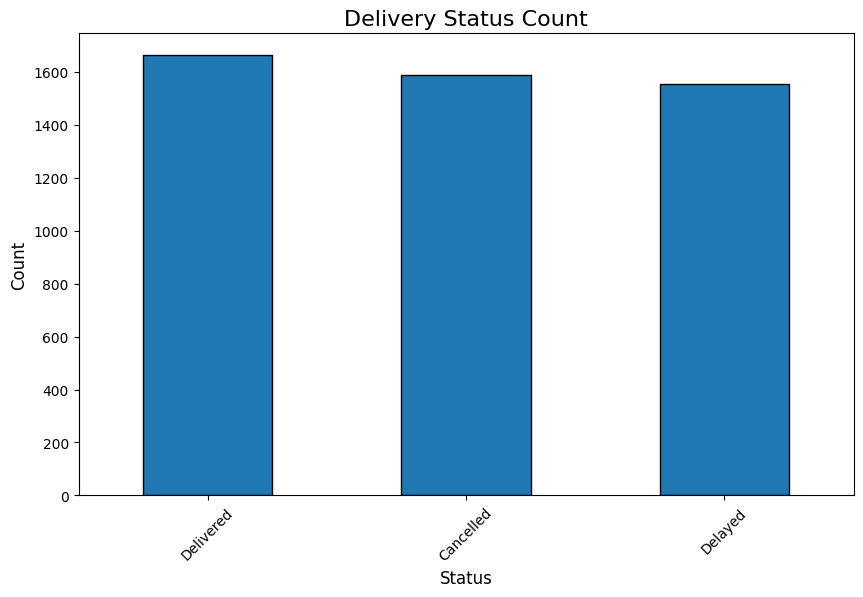

In [40]:

delivery_count = df['delivery_status'].value_counts()


plt.figure(figsize=(10,6))

delivery_count.plot(kind='bar', edgecolor='black', rot=45)

plt.title('Delivery Status Count', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

Text(0, 0.5, 'Count')

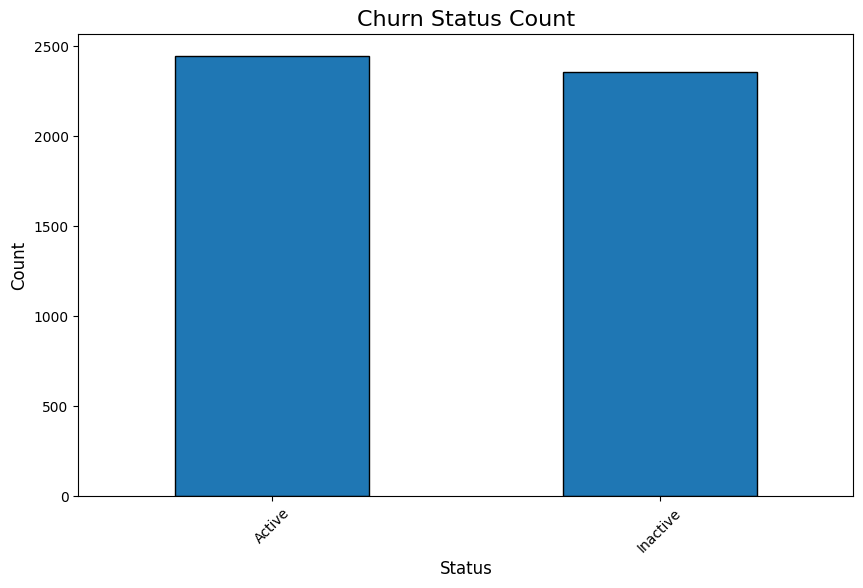

In [41]:

churn_count = df['churned'].value_counts()


plt.figure(figsize=(10,6))

churn_count.plot(kind='bar', edgecolor='black', rot=45)

plt.title('Churn Status Count', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)